# 03. Node와 Edge 패턴

---
## Node란?

Node는 그래프에서 **실제 작업을 수행하는 함수**이다.

```python
# Node의 기본 형태
def my_node(state: MyState) -> dict:
    # 1. state에서 필요한 값을 읽는다
    # 2. 필요한 작업을 수행한다
    # 3. 변경된 부분만 딕셔너리로 반환한다
    return {"key": new_value}
```
LangGraph에서 Node는 전체 State를 직접 수정하지 않고, 변경할 값만 Partial State 형태로 반환한다.

## Edge란?

Edge는 **노드 간 실행 순서**를 정의다.

```text
일반 Edge:       A  ──────────────>  B  (A실행 후 B 실행)

조건부 Edge:     A  → (조건 함수) → B  (조건이 참이면 B)
                                → C  (조건이 거짓이면 C)

START / END:     그래프의 시작점과 종료점을 나타내는 특수 노드
```

이번 실습에서는 다음 세 가지 Edge 패턴을 확인한다.

| 패턴 | 의미 | 예 |
|---|---|---|
| 순차 실행 | 노드를 정해진 순서대로 실행 | A → B → C |
| Fan-out | 하나의 노드 이후 여러 노드를 병렬 실행 | A → B, A → C |
| Fan-in | 여러 노드가 끝난 뒤 하나의 노드로 합류 | B, C → D |


## 환경변수 로딩

In [3]:
from dotenv import load_dotenv
load_dotenv(override=True, dotenv_path="../.env")

True

## 그래프 시각화 함수 정의

In [4]:
from IPython.display import Image, display

def show_graph(app, title: str = "") -> None:
    """컴파일된 LangGraph 앱의 구조를 시각화한다.

    Mermaid PNG 생성이 실패하는 환경에서는 ASCII 그래프로 대체한다.
    """
    if title:
        print(f"\n[{title}]")
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())

---

## 1. 순차 실행 그래프 (Sequential)

가장 기본적인 패턴: `START -> clean -> translate -> summarise -> END`

In [16]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class PipelineState(TypedDict):
    text: str
    cleaned: str
    translated: str
    summarized: str

def clean_node(state):
    return {"cleaned": state["text"].strip().lower()}

def translate_node(state):
    return {"translated": f"[번역됨] {state['cleaned']}"}

def summarize_node(state):
    return {"summarized": f"[요약] {state['translated'][:30]}..."}

builder = StateGraph(PipelineState)
builder.add_node("clean", clean_node)
builder.add_node("translate", translate_node)
builder.add_node("summarize", summarize_node)

builder.add_edge(START, "clean")
builder.add_edge("clean", "translate")
builder.add_edge("translate", "summarize")
builder.add_edge("summarize", END)
graph = builder.compile()

result = graph.invoke({
    "text": "Hello, LangGraph! This is a test of the modular RAG pipeline."
})

print("\n[대화 기록 전체]")
result
for key, value in result.items():
    print(f"  {key}: {value}")



[대화 기록 전체]
  text: Hello, LangGraph! This is a test of the modular RAG pipeline.
  cleaned: hello, langgraph! this is a test of the modular rag pipeline.
  translated: [번역됨] hello, langgraph! this is a test of the modular rag pipeline.
  summarized: [요약] [번역됨] hello, langgraph! this i...



[순차 실행 그래프]


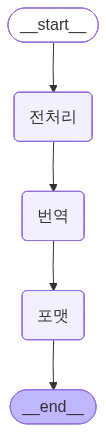

  [전처리] '  Hello World  ' → 'hello world'
  [번역] 'hello world' → '안녕 world'
  [포맷] '안녕 world' → '[결과] 안녕 WORLD'

최종 텍스트: [결과] 안녕 WORLD
실행 단계:   ['전처리', '번역', '포맷']


In [12]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from typing import Annotated
import operator

# PipelineState는 그래프 실행 중에 전달되는 상태의 구조를 정의한다.
class PipelineState(TypedDict):
    # 현재 처리중인 텍스트
    text: str
    # 지금까지 실행된 단계들의 리스트 (누적)
    steps: Annotated[list, operator.add]

def clean(state: PipelineState) -> dict:
    cleaned = state["text"].strip().lower()
    print(f"  [전처리] '{state['text']}' → '{cleaned}'")
    # text는 새 값으로 덮어쓰고, steps는 reducer(operator.add)를 통해 누적한다.
    return {"text": cleaned, "steps": ["전처리"]}

def translate(state: PipelineState) -> dict:
    """간단한 문자열 치환 방식으로 hello를 안녕으로 바꾼다."""
    translated = state["text"].replace("hello", "안녕")
    print(f"  [번역] '{state['text']}' → '{translated}'")

    # text는 새 값으로 덮어쓰고, steps는 reducer(operator.add)를 통해 누적한다.
    return {"text": translated, "steps": ["번역"]}

def format_text(state: PipelineState) -> dict:
    """최종 출력 형식에 맞게 텍스트를 가공한다."""
    formatted = f"[결과] {state['text'].upper()}"
    print(f"  [포맷] '{state['text']}' → '{formatted}'")
    return {"text": formatted, "steps": ["포맷"]}

# StateGraph는 실행 흐름을 정의하는 빌더이다.
b = StateGraph(PipelineState)

# 노드 이름과 실제 실행 함수를 연결한다.
b.add_node("전처리", clean)
b.add_node("번역", translate)
b.add_node("포맷", format_text)

# START에서 시작해 전처리 → 번역 → 포맷 순서로 실행한다.
b.add_edge(START, "전처리")
b.add_edge("전처리", "번역")
b.add_edge("번역", "포맷")
b.add_edge("포맷", END)

# compile() 이후 invoke(), stream()으로 실행할 수 있다.
app = b.compile()

show_graph(app, "순차 실행 그래프")

# 초기 State를 넣어 그래프를 실행한다.
result = app.invoke({"text": "  Hello World  ", "steps": []})

print(f"\n최종 텍스트: {result['text']}")
print(f"실행 단계:   {result['steps']}")

---

## 2. 병렬 실행 패턴 (Fan-out / Fan-in)

### Fan-out / Fan-in 예시


하나의 노드에서 여러 노드로 분기한 후 다시 합친다.

```mermaid
flowchart TD
    START([START])

    W[web<br/>search_web]
    D[db<br/>search_db]
    C[doc<br/>search_doc]

    M[merge<br/>merge_node]
    END([END])

    START --> W
    START --> D
    START --> C

    W --> M
    D --> M
    C --> M

    M --> END
```


[Fan-out/Fan-in 그래프]


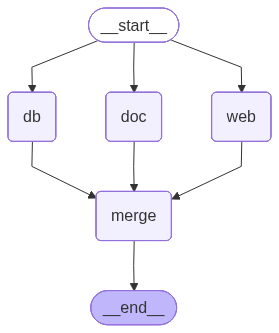

  query: LangGraph에 대해 알여줘
  results: ['[DB검색] LangGraph에 대해 알여줘의 결과', '[문서검색] LangGraph에 대해 알여줘의 결과', '[웹검색] LangGraph에 대해 알여줘의 결과', '[통합결과]\n[DB검색] LangGraph에 대해 알여줘의 결과\n[문서검색] LangGraph에 대해 알여줘의 결과\n[웹검색] LangGraph에 대해 알여줘의 결과']


In [41]:
from typing import TypedDict, Annotated
import operator

# FanState는 병렬 실행과 결과 누적을 지원하는 상태 구조를 정의한다.
class FanState(TypedDict):
    query: str
    results: Annotated[list, operator.add]  # 병렬 결과 누적

# 각 노드는 입력된 상태를 바탕으로 결과를 생성한다. 실제로는 API 호출이나 DB 쿼리가 될 수 있다.
def search_web(state):
    return {"results": [f"[웹검색] {state['query']}의 결과"]}

def search_db(state):
    return {"results": [f"[DB검색] {state['query']}의 결과"]}

def search_doc(state):
    return {"results": [f"[문서검색] {state['query']}의 결과"]}

def merge_node(state):
    combined = "\n".join(state["results"])
    return {"results": [f"[통합결과]\n{combined}"]}

builder = StateGraph(FanState)

# 노드 등록
builder.add_node("web", search_web)
builder.add_node("db", search_db)
builder.add_node("doc", search_doc)
builder.add_node("merge", merge_node)

# Fan-out: START → 3개 노드 병렬
builder.add_edge(START, "web")
builder.add_edge(START, "db")
builder.add_edge(START, "doc")

# Fan-in: 3개 노드 → merge
# builder.add_edge("web", "merge")
# builder.add_edge("db", "merge")
# builder.add_edge("doc", "merge")
builder.add_edge(["web", "db", "doc"], "merge")
builder.add_edge("merge", END)
graph = builder.compile()

show_graph(graph, "Fan-out/Fan-in 그래프")

result = graph.invoke({"query": "LangGraph에 대해 알여줘", "results": []})
# result  
for key, value in result.items():
    print(f"  {key}: {value}")



### stream_mode="updates" 활용

In [ ]:
print("=== graph.stream() 실행: updates 모드 ===")

inputs = {
    "query": "LangGraph에 대해 알려줘",
    "results": []
}

for event in graph.stream(inputs, stream_mode="updates"):
    print(event)
    print("-" * 52)

=== graph.stream() 실행: updates 모드 ===
{'db': {'results': ['[DB검색] LangGraph에 대해 알려줘의 결과']}}
----------------------------------------------------
{'doc': {'results': ['[문서검색] LangGraph에 대해 알려줘의 결과']}}
----------------------------------------------------
{'web': {'results': ['[웹검색] LangGraph에 대해 알려줘의 결과']}}
----------------------------------------------------
{'merge': {'results': ['[통합결과]\n[DB검색] LangGraph에 대해 알려줘의 결과\n[문서검색] LangGraph에 대해 알려줘의 결과\n[웹검색] LangGraph에 대해 알려줘의 결과']}}
----------------------------------------------------


: 

### 계산기

```mermaid
flowchart TD
    START([START]) --> S[시작<br/>start_node]

    S --> A[경로A<br/>path_a<br/>value × 2]
    S --> B[경로B<br/>path_b<br/>value + 100]

    A --> M[합산<br/>merge_node<br/>results 출력]
    B --> M

    M --> END([END])
```


[병렬(Fan-out/Fan-in) 그래프]


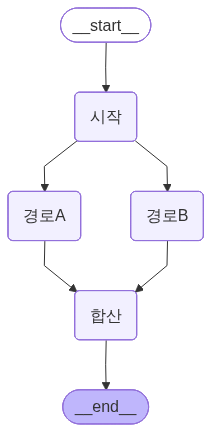

  [시작] value=5
  [경로A] 5 x 2 = 10
  [경로B] 5 + 100 = 105
  [합산] 수집된 결과: ['A결과=10', 'B결과=105']

최종 결과: ['A결과=10', 'B결과=105']


In [36]:
class FanState(TypedDict):
    # 두 경로가 공통으로 읽는 입력값
    value: int

    # 경로A와 경로B가 각각 반환한 결과를 하나의 리스트로 누적한다.
    # 병렬 노드들이 같은 key를 동시에 업데이트할 수 있으므로 reducer가 필요하다.
    results: Annotated[list[str], operator.add]

def start_node(state: FanState) -> dict:
    """분기 전에 현재 입력값을 확인하는 시작 노드이다."""
    print(f"  [시작] value={state['value']}")

    # 변경할 State가 없으면 빈 딕셔너리를 반환한다.
    return {}


def path_a(state: FanState) -> dict:
    """첫 번째 병렬 경로: 입력값에 2를 곱한다."""
    r = state["value"] * 2
    print(f"  [경로A] {state['value']} x 2 = {r}")

    # results는 reducer에 의해 기존 리스트 뒤에 누적된다.
    return {"results": [f"A결과={r}"]}


def path_b(state: FanState) -> dict:
    """두 번째 병렬 경로: 입력값에 100을 더한다."""
    r = state["value"] + 100
    print(f"  [경로B] {state['value']} + 100 = {r}")
    return {"results": [f"B결과={r}"]}


def merge_node(state: FanState) -> dict:
    """두 병렬 경로의 결과가 모두 모인 뒤 실행되는 합류 노드이다."""
    print(f"  [합산] 수집된 결과: {state['results']}")

    # 결과를 출력만 하므로 State 변경은 없다.
    return {}


b = StateGraph(FanState)

b.add_node("시작", start_node)
b.add_node("경로A", path_a)
b.add_node("경로B", path_b)
b.add_node("합산", merge_node)

b.add_edge(START, "시작")

# Fan-out: 하나의 노드 실행 후 여러 노드를 병렬로 실행한다.
b.add_edge("시작", "경로A")
b.add_edge("시작", "경로B")

# Fan-in: 경로A와 경로B가 모두 끝난 뒤 합산 노드를 실행한다.
# list 형태의 start_key를 사용하면 여러 시작 노드의 완료를 기다린다.
b.add_edge(["경로A", "경로B"], "합산")

b.add_edge("합산", END)

graph = b.compile()

show_graph(graph, "병렬(Fan-out/Fan-in) 그래프")

result = graph.invoke({"value": 5, "results": []})
print(f"\n최종 결과: {result['results']}")

---

## 3. 스트림으로 각 노드 결과 추적

In [39]:
print("=== stream()으로 단계별 State 변화 추적 ===")
print(f"{'단계':<10} {'State 변화':<40}")
print("-" * 52)

# stream_mode="updates"를 사용하면 각 노드가 반환한 업데이트만 확인할 수 있다.
for event in graph.stream(
    {"value": 5, "results": []},
    stream_mode="updates",
):
    for node_name, output in event.items():
        print(f"{node_name:<10} {str(output):<40}")
        print("-" * 52)


=== stream()으로 단계별 State 변화 추적 ===
단계         State 변화                                
----------------------------------------------------
  [시작] value=5
시작         None                                    
----------------------------------------------------
  [경로A] 5 x 2 = 10
경로A        {'results': ['A결과=10']}                 
----------------------------------------------------
  [경로B] 5 + 100 = 105
경로B        {'results': ['B결과=105']}                
----------------------------------------------------
  [합산] 수집된 결과: ['A결과=10', 'B결과=105']
합산         None                                    
----------------------------------------------------


---

## 4. 그래프 구조 정보 확인

In [34]:
print("=== 그래프 구조 정보 ===")

# get_graph()는 컴파일된 그래프의 구조 정보를 반환한다.
graph = graph.get_graph()

print("\n[노드 목록]")
for node in graph.nodes:
    print(f"  - {node}")

print("\n[엣지 목록]")
for edge in graph.edges:
    print(f"  {edge.source} → {edge.target}")

print("\n[Mermaid 구문]")
print(graph.draw_mermaid())


=== 그래프 구조 정보 ===

[노드 목록]
  - __start__
  - 시작
  - 경로A
  - 경로B
  - 합산
  - __end__

[엣지 목록]
  __start__ → 시작
  경로A → 합산
  경로B → 합산
  시작 → 경로A
  시작 → 경로B
  합산 → __end__

[Mermaid 구문]
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	\c2dc\c791(시작)
	\acbd\b85cA(경로A)
	\acbd\b85cB(경로B)
	\d569\c0b0(합산)
	__end__([<p>__end__</p>]):::last
	__start__ --> \c2dc\c791;
	\acbd\b85cA --> \d569\c0b0;
	\acbd\b85cB --> \d569\c0b0;
	\c2dc\c791 --> \acbd\b85cA;
	\c2dc\c791 --> \acbd\b85cB;
	\d569\c0b0 --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



---

## 정리

```python
# 1. 순차 실행
builder.add_edge("A", "B")

# 2. Fan-out: 한 노드 이후 여러 노드를 병렬 실행
builder.add_edge("A", "B")
builder.add_edge("A", "C")

# 3. Fan-in: 여러 노드가 모두 끝난 뒤 하나의 노드 실행
builder.add_edge(["B", "C"], "D")

# 4. 그래프 실행
app = builder.compile()
result = app.invoke(initial_state)

# 5. 단계별 업데이트 확인
for event in app.stream(initial_state, stream_mode="updates"):
    print(event)

# 6. 시각화
app.get_graph().draw_ascii()         # 텍스트 그래프
app.get_graph().draw_mermaid()       # Mermaid 구문
app.get_graph().draw_mermaid_png()   # PNG 이미지
```

### 핵심 포인트

| 항목 | 의미 |
|---|---|
| Node | 현재 State를 입력으로 받아 Partial State를 반환하는 함수 |
| Edge | 다음에 실행할 Node를 지정하는 연결 |
| Fan-out | 하나의 노드 이후 여러 노드를 병렬로 실행하는 구조 |
| Fan-in | 여러 노드의 결과를 모은 뒤 하나의 노드로 합류하는 구조 |
| Reducer | 병렬 노드가 같은 State key를 업데이트할 때 값을 병합하는 규칙 |

→ 다음: **조건부 Edge** (`04_conditional_edge.ipynb`)
